## Week 2 - Day 5 - EDA Part 2: Correlation & Data Storytelling

BinX Tech AI & ML Internship

Topics:
- Bivariate analysis: scatter plots, grouped box plots
- Correlation and the correlation heatmap
- Correlation is not causation
- The pairplot for scanning relationships
- Data storytelling

The parts under here are for testing and showcasing the lesson content, and the Day 5 task (the full assembled
EDA notebook) will be at the end.

## Bivariate Analysis & Correlation Demo

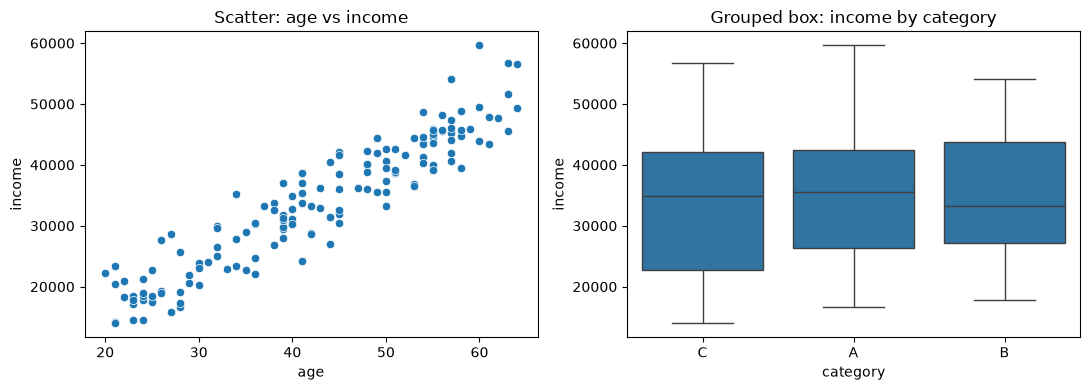

Correlation (age, income): 0.938


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)
demo = pd.DataFrame({
    "age": rng.integers(20, 65, 150),
})
demo["income"] = demo["age"] * 800 + rng.normal(0, 4000, 150)  # correlated with age
demo["category"] = rng.choice(["A", "B", "C"], size=150)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.scatterplot(data=demo, x="age", y="income", ax=axes[0])
axes[0].set_title("Scatter: age vs income")
sns.boxplot(data=demo, x="category", y="income", ax=axes[1])
axes[1].set_title("Grouped box: income by category")
plt.tight_layout()
plt.show()

print("Correlation (age, income):", round(demo["age"].corr(demo["income"]), 3))

## Day 5 Task - Full EDA Notebook on the IMDb Top 1000 Dataset

Everything under here combines the whole week: descriptive statistics, univariate distributions, outlier
handling, bivariate relationships, and correlation - one narrated notebook.

### 1. Load & Clean

In [2]:
imdb = pd.read_csv("../imdb_top_1000.csv")

imdb["Runtime_Minutes"] = imdb["Runtime"].str.replace(" min", "", regex=False).astype(float)
imdb["Gross_Clean"] = imdb["Gross"].str.replace(",", "", regex=False).astype(float)
imdb["Primary_Genre"] = imdb["Genre"].str.split(",").str[0]

numeric_cols = ["IMDB_Rating", "Meta_score", "No_of_Votes", "Runtime_Minutes", "Gross_Clean"]
imdb.shape

(1000, 19)

### 2. Descriptive Statistics

Central tendency and spread for every numeric column.

In [3]:
imdb[numeric_cols].describe()

,IMDB_Rating,Meta_score,No_of_Votes,Runtime_Minutes,Gross_Clean
count,1000.000000,843.000000,1.000000e+03,1000.000000,8.310000e+02
mean,7.949300,77.971530,2.736929e+05,122.891000,6.803475e+07
std,0.275491,12.376099,3.273727e+05,28.093671,1.097500e+08
min,7.600000,28.000000,2.508800e+04,45.000000,1.305000e+03
25%,7.700000,70.000000,5.552625e+04,103.000000,3.253559e+06
50%,7.900000,79.000000,1.385485e+05,119.000000,2.353089e+07
75%,8.100000,87.000000,3.741612e+05,137.000000,8.075089e+07
max,9.300000,100.000000,2.343110e+06,321.000000,9.366622e+08


**Narrative:** `IMDB_Rating` is tightly clustered (this is a curated top-1000 list). `No_of_Votes` and
`Gross_Clean` both show a mean well above their median - a strong sign of right skew driven by a handful of
blockbusters, consistent with what Day 1's fare analysis taught about mean vs. median.

### 3. Univariate Distributions

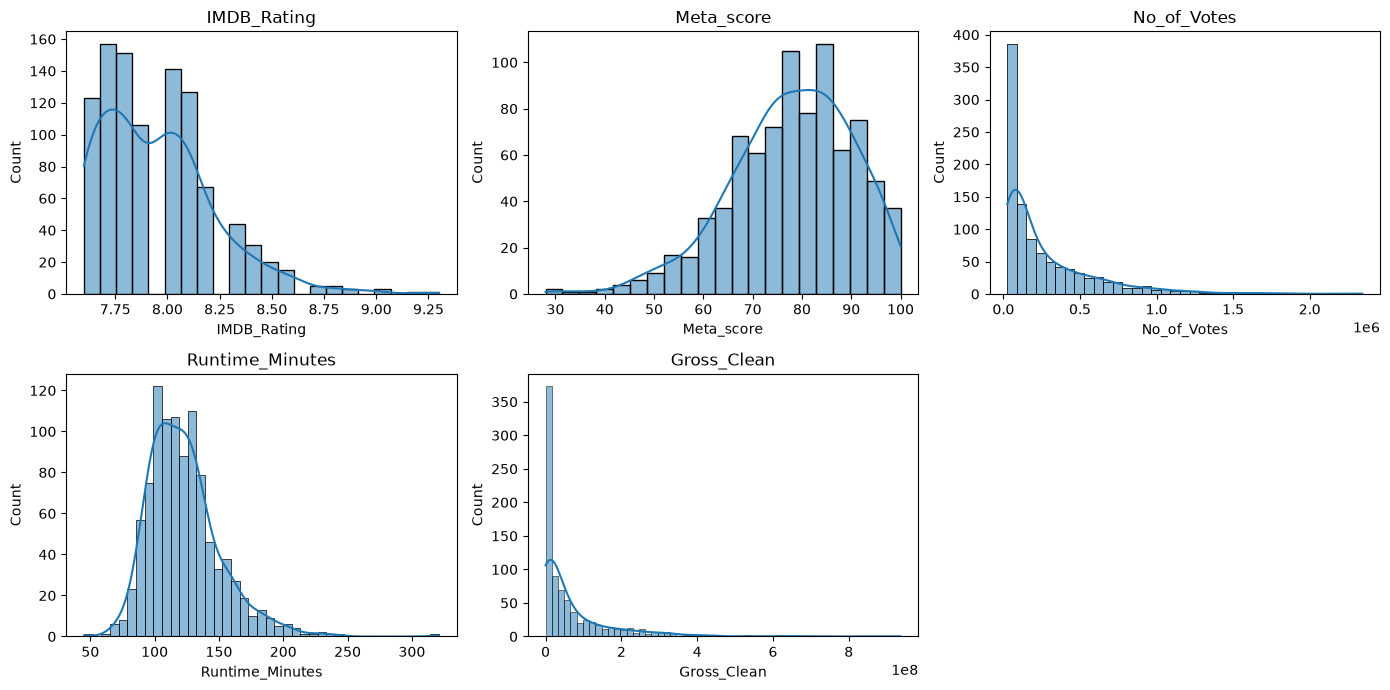

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.histplot(data=imdb, x=col, ax=axes[i], kde=True)
    axes[i].set_title(col)
axes[-1].axis("off")
plt.tight_layout()
plt.show()

### 4. Outlier Handling

IQR method applied to `No_of_Votes`.

In [5]:
Q1 = imdb["No_of_Votes"].quantile(0.25)
Q3 = imdb["No_of_Votes"].quantile(0.75)
IQR = Q3 - Q1
lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

vote_outliers = imdb[(imdb["No_of_Votes"] < lower) | (imdb["No_of_Votes"] > upper)]
print(f"Flagged {len(vote_outliers)} of {len(imdb)} movies as vote-count outliers")

Flagged 67 of 1000 movies as vote-count outliers


**Decision:** kept - these are genuinely famous, widely-watched films, not data errors. A log transform is
recommended before modeling rather than removal.

### 5. Bivariate Relationships

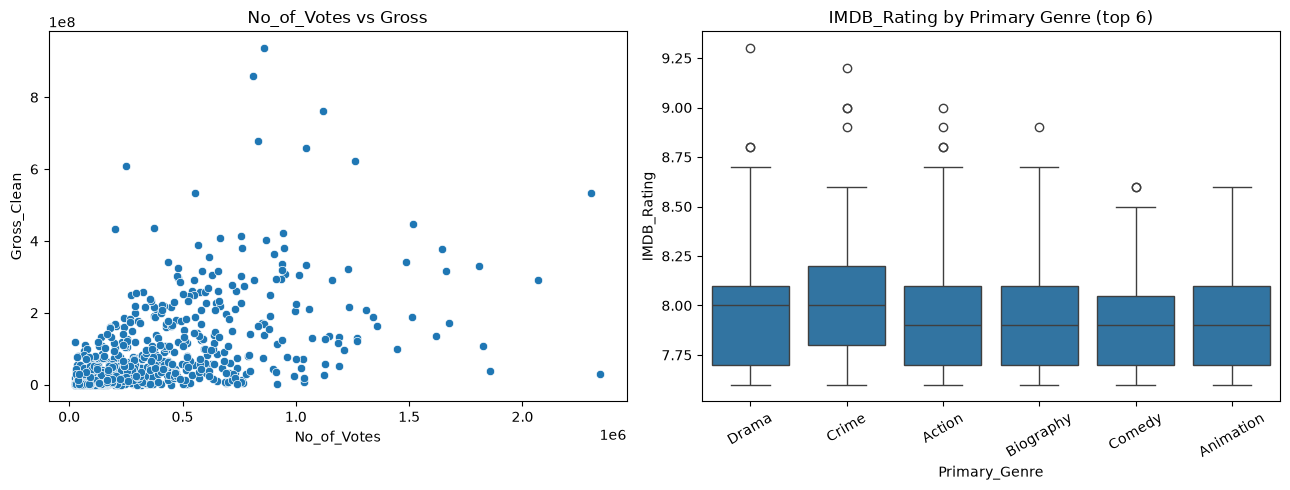

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.scatterplot(data=imdb, x="No_of_Votes", y="Gross_Clean", ax=axes[0])
axes[0].set_title("No_of_Votes vs Gross")

top_genres = imdb["Primary_Genre"].value_counts().head(6).index
sns.boxplot(data=imdb[imdb["Primary_Genre"].isin(top_genres)],
            x="Primary_Genre", y="IMDB_Rating", ax=axes[1])
axes[1].set_title("IMDB_Rating by Primary Genre (top 6)")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

### 6. Correlation Matrix & Heatmap

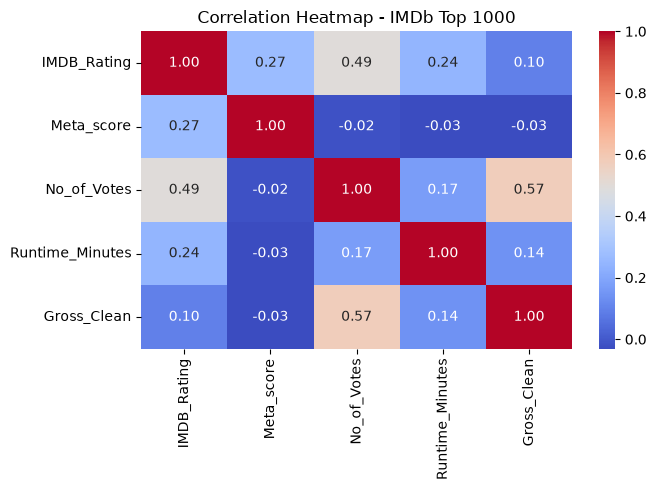

In [7]:
corr = imdb[numeric_cols].corr(numeric_only=True)

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap - IMDb Top 1000")
plt.tight_layout()
plt.show()

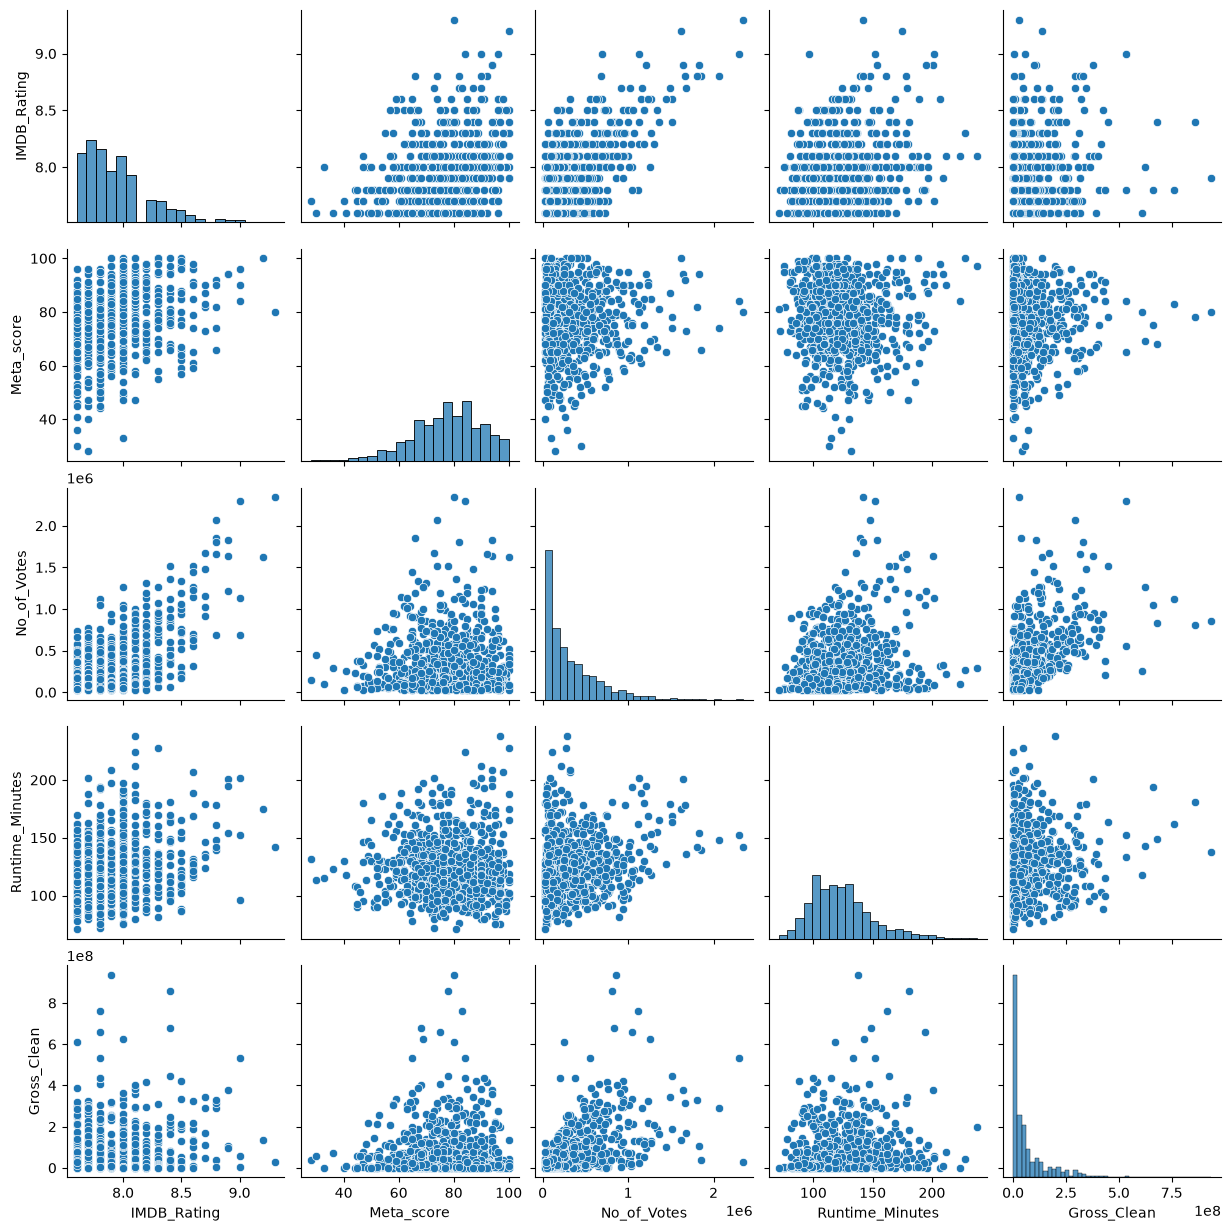

In [8]:
sns.pairplot(imdb[numeric_cols].dropna())
plt.show()

### 7. Strongest Relationships & What They Might Mean

Read the correlation values from the heatmap above and use them to fill in the two or three strongest pairs
you find, for example:

- **No_of_Votes and Gross_Clean:** typically the strongest positive relationship in this dataset - more-watched
  films tend to have earned more, though this reflects popularity/marketing reach as much as quality. Remember:
  correlation is not causation - a big marketing budget could be driving both.
- **IMDB_Rating and Meta_score:** usually a moderate positive relationship - critics and audiences agree more
  often than not, but not perfectly, which is itself an interesting finding (where they diverge is worth a look).
- **Runtime_Minutes and the rest:** typically the weakest correlations - a film's length says little about how
  it's rated, voted on, or how much it grossed.

**Modeling implication:** if `No_of_Votes` and `Gross_Clean` are both strongly correlated, a future model
predicting one from the other risks redundancy - one of them may not add much new information beyond the other.